In [ ]:
import os
import uuid
from langgraph.checkpoint.memory import MemorySaver
from langgraph.constants import START,END
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from typing import Annotated

In [ ]:



class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


In [6]:
graph_builder = StateGraph(State)

In [12]:
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')
llm=ChatGoogleGenerativeAI(model="gemini-2.0-flash",api_key=GOOGLE_API_KEY)


In [13]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


In [14]:
graph_builder.add_node("chatbot", chatbot)


In [15]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [16]:
graph = graph_builder.compile()


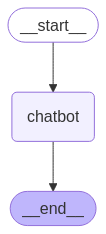

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [18]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)




In [ ]:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break


In [22]:
hello="tell about data streaming"
data=graph.invoke({"messages": [{"role": "user", "content": hello}]})

In [33]:
data["messages"]

[HumanMessage(content='tell about data streaming', additional_kwargs={}, response_metadata={}, id='1c04368f-6fa6-4451-b4bc-9f5fc500b031'),
 AIMessage(content="Okay, let's dive into the world of data streaming!\n\n**What is Data Streaming?**\n\nData streaming is the continuous transmission of data records from a source to a destination in real-time. Instead of storing data in a batch and processing it later, data is processed as it arrives, allowing for immediate insights and actions.  Think of it like a flowing river of information, rather than a static lake.\n\n**Key Characteristics of Data Streaming:**\n\n*   **Real-time:** Data is processed and analyzed with minimal delay. This is crucial for applications that require immediate responses.\n*   **Continuous:**  Data is transmitted constantly, not in discrete batches.\n*   **High Volume:** Data streams often involve large volumes of data, requiring scalable infrastructure to handle the throughput.\n*   **Variety:** Data can come from 

In [34]:
for i in data["messages"][-1]:
    print(i)

('content', "Okay, let's dive into the world of data streaming!\n\n**What is Data Streaming?**\n\nData streaming is the continuous transmission of data records from a source to a destination in real-time. Instead of storing data in a batch and processing it later, data is processed as it arrives, allowing for immediate insights and actions.  Think of it like a flowing river of information, rather than a static lake.\n\n**Key Characteristics of Data Streaming:**\n\n*   **Real-time:** Data is processed and analyzed with minimal delay. This is crucial for applications that require immediate responses.\n*   **Continuous:**  Data is transmitted constantly, not in discrete batches.\n*   **High Volume:** Data streams often involve large volumes of data, requiring scalable infrastructure to handle the throughput.\n*   **Variety:** Data can come from various sources and in different formats (structured, semi-structured, unstructured).\n*   **Velocity:** Data arrives at high speeds, requiring fa